In [16]:
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

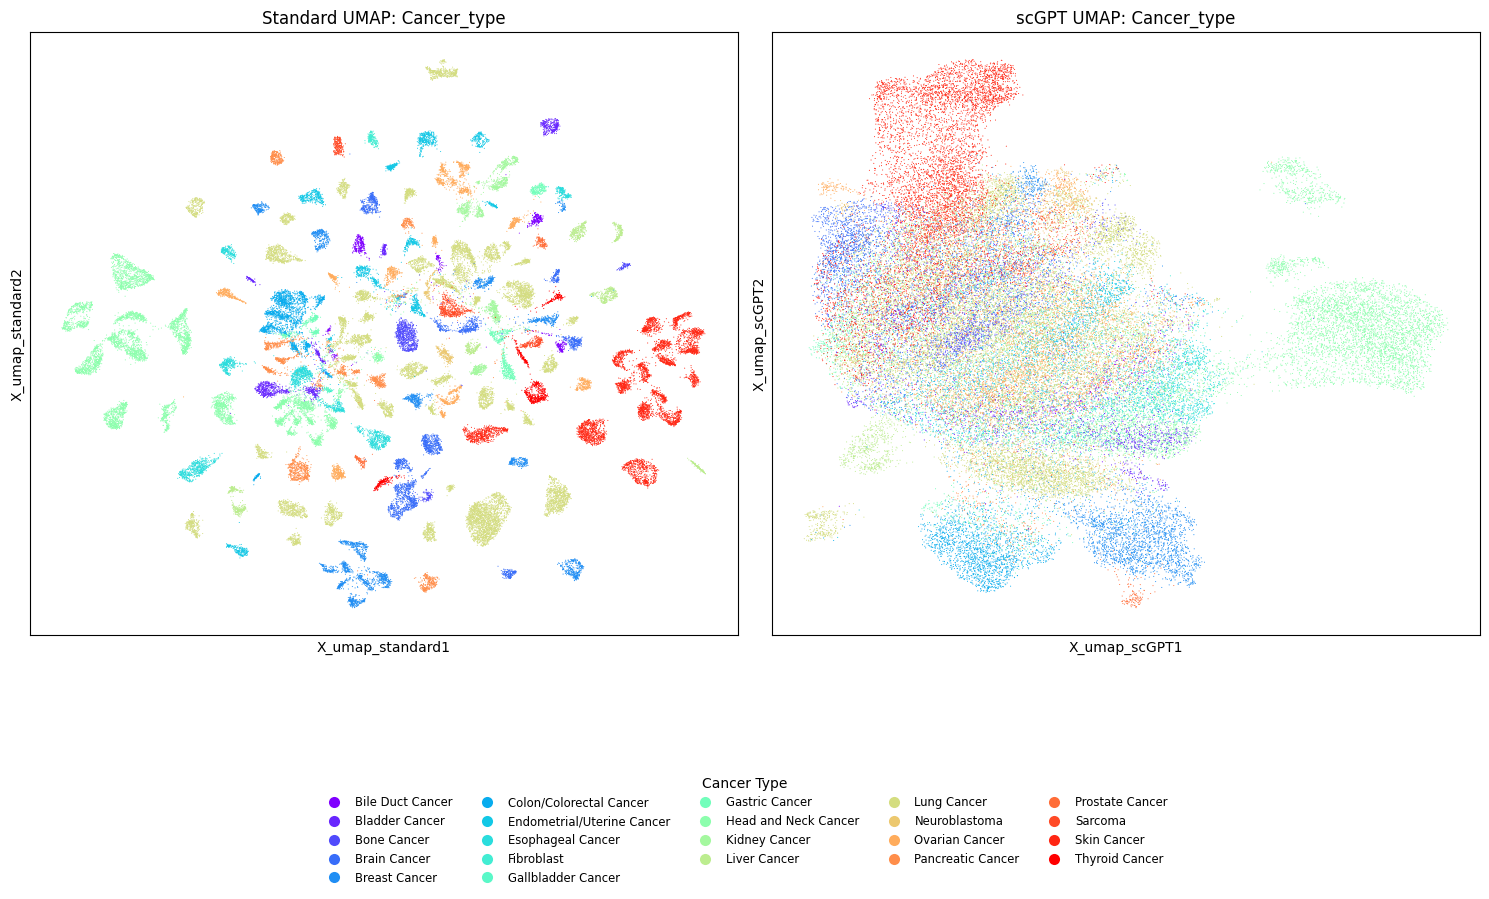

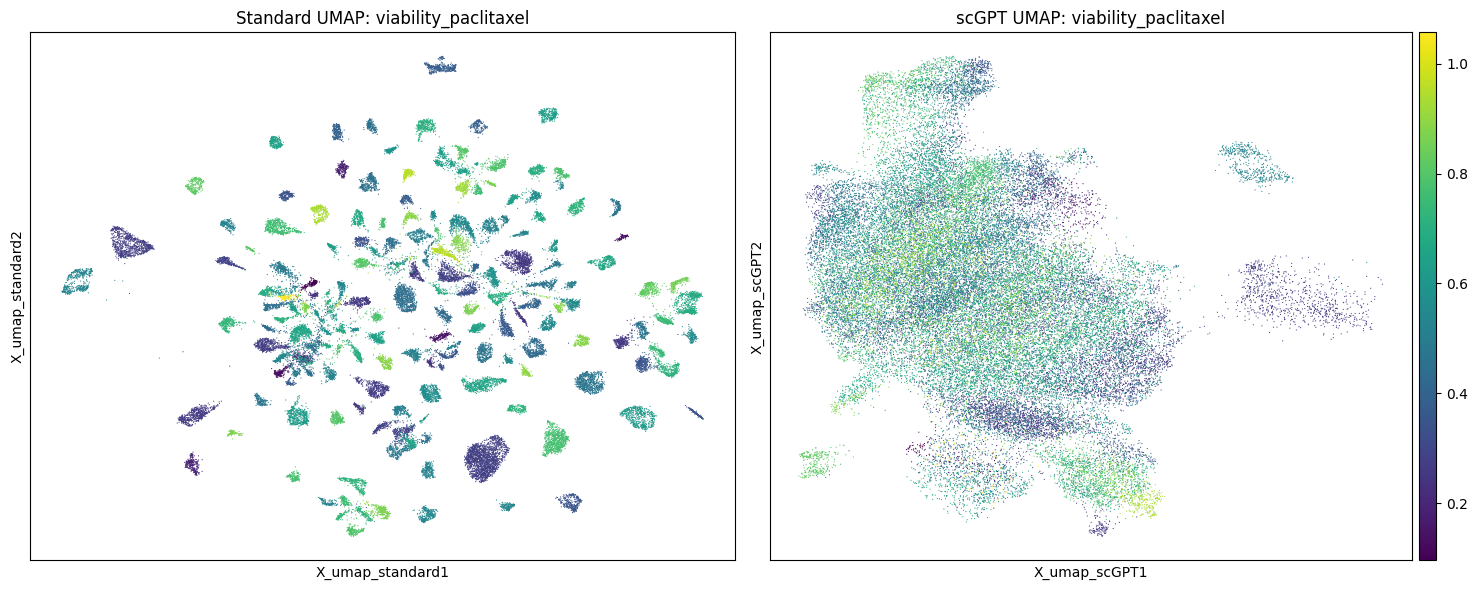

In [17]:
# 1. Load the file you just saved
file_path = "/Users/selin/Desktop/OncoTox/data/scRNAseq_SCP542/metadata/SCP542_CCLE_scGPT_human_embeddings_with_targets.h5ad"
adata = sc.read_h5ad(file_path)

# 2. Standard Pipeline (Baseline)
if "X_pca" not in adata.obsm:
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    #sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    sc.pp.pca(adata)

sc.pp.neighbors(adata, n_neighbors=15, n_pcs=40, key_added='standard')
sc.tl.umap(adata, neighbors_key='standard')
adata.obsm['X_umap_standard'] = adata.obsm['X_umap'].copy()

# 3. scGPT Pipeline
sc.pp.neighbors(adata, use_rep="X_scGPT", n_neighbors=15, key_added='scGPT')
sc.tl.umap(adata, neighbors_key='scGPT')
adata.obsm['X_umap_scGPT'] = adata.obsm['X_umap'].copy()

# 4. Visualization: The Advisor Proof
plot_columns = ['Cancer_type', 'viability_paclitaxel']

# Filter the dataset to only include cells that ACTUALLY have a paclitaxel score
adata_tested = adata[adata.obs['train_mask_paclitaxel'] == True].copy()

for col in plot_columns:
    # Give the Cancer_type figure more vertical space to fit the legend below
    fig, axes = plt.subplots(1, 2, figsize=(15, 9 if col == 'Cancer_type' else 6))

    plot_adata = adata_tested if col == 'viability_paclitaxel' else adata

    # We use cmap for continuous data (viability), and palette for categorical data (Cancer_type)
    color_map = 'viridis' if col == 'viability_paclitaxel' else None
    cat_palette = 'rainbow' if col == 'Cancer_type' else None

    # Plot Standard UMAP
    # We set colorbar_loc=None and legend_loc='none' to avoid duplicate legends on the left plot
    sc.pl.embedding(plot_adata, basis='X_umap_standard', color=col,
                    show=False, ax=axes[0], title=f"Standard UMAP: {col}",
                    cmap=color_map, palette=cat_palette,
                    colorbar_loc=None, legend_loc='none')

    # Plot scGPT UMAP
    # For the drug score, let Scanpy draw the continuous colorbar normally on the right.
    # For Cancer_type, turn off the legend so we can build a custom one below.
    sc.pl.embedding(plot_adata, basis='X_umap_scGPT', color=col,
                    show=False, ax=axes[1], title=f"scGPT UMAP: {col}",
                    cmap=color_map, palette=cat_palette,
                    legend_loc='none' if col == 'Cancer_type' else 'right margin')

    if col == 'Cancer_type':
        # 1. Grab the categories and the colors Scanpy just generated from the rainbow palette
        categories = plot_adata.obs[col].cat.categories
        colors = plot_adata.uns[f'{col}_colors']

        # 2. Create a custom dot (Line2D) for each category
        handles = [mlines.Line2D([], [], color='none', marker='o',
        markerfacecolor=colors[i], markeredgecolor='none',
        markersize=8, label=cat) for i, cat in enumerate(categories)]

        # 3. Add the legend to the bottom center of the whole figure, split into 5 columns
        fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, 0.0),
        ncol=5, frameon=False, title="Cancer Type", fontsize='small')

        # 4. Adjust layout to squish the plots up slightly, leaving the bottom 25% empty for the legend
        plt.tight_layout(rect=[0, 0.25, 1, 1])
    else:
        # Standard layout for the continuous drug plot
        plt.tight_layout()

    plt.show()